<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/NLP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# 1.Importing Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# SpaCy
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, precision_score, f1_score

In [18]:
# 5.Give meaningful column names
df.columns=["Tweet_ID","Entity","Sentiment","Text"]
print("\nfirst five records:")
print(df.head())

# 6. Basic dataset information
print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())



first five records:
   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Dataset Shape:
(74682, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
m

In [19]:
# 7. Remove Missing Values
df=df.dropna(subset=['Text','Sentiment'])
print("\nDataset after removing missing values:")
print(df.shape)

# 8. Remove Irrelevant Class
df=df[df['Sentiment'].isin(['Positive','Negative','Neutral'])]
print("\nSentiment distribution after removing Irrelevant:")
print(df['Sentiment'].value_counts())


Dataset after removing missing values:
(73996, 4)

Sentiment distribution after removing Irrelevant:
Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


In [20]:
# 9. Text Preprocessing function
stop_words=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()
def clean_text(text):
  text=text.lower()
  text=re.sub(r"http\S+","",text)
  text=re.sub(r'@\W+','',text)
  text=re.sub(r'#','',text)
  text=re.sub(r'\d+','',text)
  text=text.translate(str.maketrans("","",string.punctuation))
  # remove extra space
  text=re.sub(r"\s+"," ",text).strip()
  # Tokenization
  words=text.split()
  words=[word for word in words
         if word not in stop_words]
  # Lemmitization
  words=[lemmatizer.lemmatize(word) for word in words]
  return ' '.join(words)

In [21]:
# 10. Original and Cleaned Text
df['Clean_Text']=df["Text"].apply(clean_text)
print('Original and Cleaned Text:')
print(df[['Text','Clean_Text']].head())


# 11.Remove empty text records
df=df[df['Clean_Text'].str.strip()!=""]



Original and Cleaned Text:
                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                     Clean_Text  
0  im getting borderland murder  
1            coming border kill  
2    im getting borderland kill  
3   im coming borderland murder  
4  im getting borderland murder  


In [23]:
def spacy_preprocess_batch(texts):
    results = []

    for doc in nlp.pipe(texts, batch_size=100):
        tokens = []

        for token in doc:
            if (
                not token.is_stop
                and not token.is_punct
                and not token.is_space
            ):
                tokens.append(token.lemma_.lower())

        results.append(" ".join(tokens))

    return results


# Apply SpaCy preprocessing in batches
df["Preprocessed_Text"] = spacy_preprocess_batch(
    df["Clean_Text"].tolist()
)

# Display result
print("\nText after SpaCy preprocessing:")
print(
    df[["Text", "Preprocessed_Text"]].head(10)
)


Text after SpaCy preprocessing:
                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   
5  im getting into borderlands and i can murder y...   
6  So I spent a few hours making something for fu...   
7  So I spent a couple of hours doing something f...   
8  So I spent a few hours doing something for fun...   
9  So I spent a few hours making something for fu...   

                                   Preprocessed_Text  
0                            m get borderland murder  
1                                   come border kill  
2                              m get borderland kill  
3                           m come borderland murder  
4                            m get borderland murder  
5                   

In [27]:
# 13. Define Features and Targets
X=df["Preprocessed_Text"]
y=df["Sentiment"]

# 14. Split data into training and testing sets
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )
print("\nTraining samples:",len(X_train))
print("Testing samples:",len(X_test))


Training samples: 47809
Testing samples: 11953


In [28]:
# 15. TF-IDF Feature Extraction
vectorizer=TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
    )
# Learn vocabulary from training data
X_train_tfidf=vectorizer.fit_transform(X_train)

# transform testing data
X_test_tfidf=vectorizer.transform(X_test)

print("\nTF-IDF Training Shape:")
print("Shape of X_train_tfidf:",X_train_tfidf.shape)
print("\nTF-IDF Testing Shape:")
print("Shape of X_test_tfidf:",X_test_tfidf.shape)


TF-IDF Training Shape:
Shape of X_train_tfidf: (47809, 10000)

TF-IDF Testing Shape:
Shape of X_test_tfidf: (11953, 10000)


In [29]:
#16
model = MultinomialNB()
#17 train the model
model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

In [30]:
y_pred=model.predict(X_test_tfidf)

In [32]:
accuracy=accuracy_score(y_test,y_pred)
print(f"\nAccuracy: {accuracy:.4f}")


Accuracy: 0.7550


In [36]:
precision=precision_score(y_test,y_pred,average="weighted")
print(f"\nPrecision: {precision:.4f}")


Precision: 0.7564


In [37]:
recall=recall_score(y_test,y_pred,average="weighted")
print(f"\nRecall: {recall:.4f}")


Recall: 0.7550


In [42]:
f1=f1_score(y_test,y_pred,average="weighted")
print(f"\nF1 Score: {f1:.4f}")


F1 Score: 0.7520


In [39]:
print("\n Classification Report:")
print(classification_report(y_test,y_pred))


 Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.84      0.79      4385
     Neutral       0.77      0.61      0.68      3532
    Positive       0.75      0.79      0.77      4036

    accuracy                           0.76     11953
   macro avg       0.76      0.75      0.75     11953
weighted avg       0.76      0.76      0.75     11953



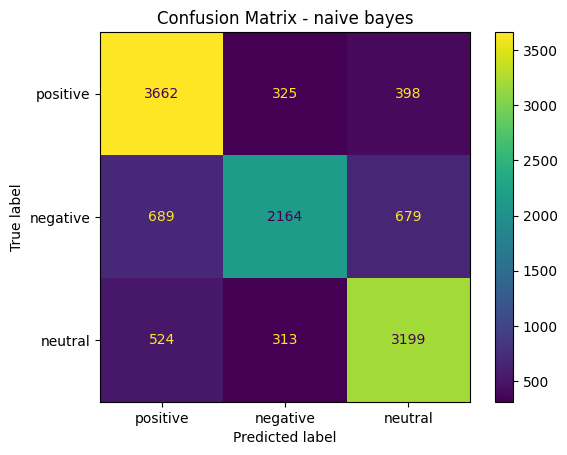

In [50]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['positive','negative','neutral'])
disp.plot()
plt.title("Confusion Matrix - naive bayes")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

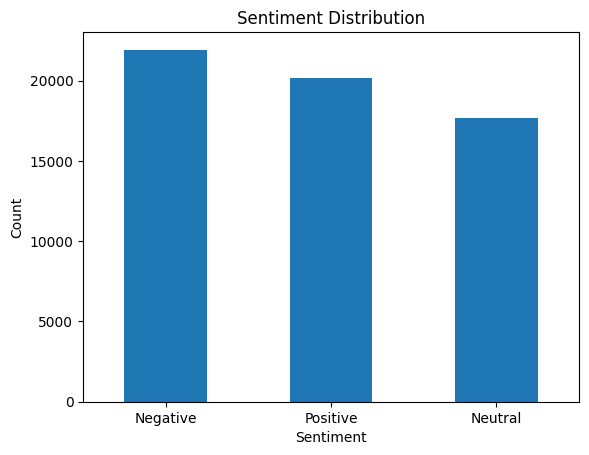

In [53]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Distribution')
plt.xticks(rotation=0)
plt.show

In [60]:
def predict_sentiment(text):
  cleaned=clean_text(text)
  processed=spacy_preprocess(cleaned)
  text_vector=vectorizer.transform([processed])
  prediction=model.predict(text_vector)[0]
  probabilities=model.predict_proba(text_vector)[0]

  print('\n input text : ')
  print(text)

  print("\n predicted sentiments : ")
  print(prediction)

  print("\n prediction probabilites ")
  for label , probabilites in zip(
      model.classes_,probabilities
  ):
    print(f"{label}: {probabilities*100:.f}%")
  return prediction


test the model on unseen data